In [1]:
pip install gensim

     ---------------------------------------- 24.4/24.4 MB 2.3 MB/s eta 0:00:00
     ---------------------------------------- 64.1/64.1 kB 3.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
df = pd.read_csv('../IMDB Dataset.csv')

# Cleaning function
def clean_review(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df['cleaned_review'] = df['review'].apply(clean_review)

# Labels
y = df['sentiment'].map({'negative': 0, 'positive': 1}).values

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 20000   # vocabulary size
max_len = 200       # max review length

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_review'])
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])
X = pad_sequences(sequences, maxlen=max_len)

# Train/val/test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Convert to tensors
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1,1)
X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val).reshape(-1,1)
X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1,1)

# Data loaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64)

In [4]:
import gensim.downloader as api
import numpy as np

# Load pretrained Word2Vec (GoogleNews, 300d)
word2vec = api.load("word2vec-google-news-300")  # ~1.6GB

embedding_dim = 300
vocab_size = max_words

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in word2vec:
        embedding_matrix[i] = word2vec[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))  # OOV words

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [5]:
import torch.nn as nn

class LSTM_Improved(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, embedding_matrix):
        super(LSTM_Improved, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.embedding.weight.data.copy_(torch.tensor(embedding_matrix))
        self.embedding.weight.requires_grad = False  # freeze embeddings

        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim*2, 1)  # times 2 because bidirectional
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        # Concatenate forward and backward hidden
        hidden = torch.cat((hidden[0], hidden[1]), dim=1)
        x = self.dropout(hidden)
        x = self.fc(x)
        return self.sigmoid(x)

hidden_dim = 128
model = LSTM_Improved(vocab_size, embedding_dim, hidden_dim, embedding_matrix)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

LSTM_Improved(
  (embedding): Embedding(20000, 300)
  (lstm): LSTM(300, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
num_epochs = 10
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        pred = (outputs >= 0.5).float()
        train_total += batch_y.size(0)
        train_correct += (pred == batch_y).sum().item()
        
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            pred = (outputs >= 0.5).float()
            val_total += batch_y.size(0)
            val_correct += (pred == batch_y).sum().item()
            
    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))
    train_accuracies.append(100*train_correct/train_total)
    val_accuracies.append(100*val_correct/val_total)
    
    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_accuracies[-1]:.2f}% | Val Acc: {val_accuracies[-1]:.2f}%")

Epoch 1/10 | Train Acc: 62.90% | Val Acc: 71.05%
Epoch 2/10 | Train Acc: 74.86% | Val Acc: 75.34%
Epoch 3/10 | Train Acc: 76.67% | Val Acc: 80.73%
Epoch 4/10 | Train Acc: 79.71% | Val Acc: 80.74%
Epoch 5/10 | Train Acc: 81.70% | Val Acc: 81.33%
Epoch 6/10 | Train Acc: 84.22% | Val Acc: 85.48%
Epoch 7/10 | Train Acc: 86.22% | Val Acc: 86.78%
Epoch 8/10 | Train Acc: 88.16% | Val Acc: 86.10%
Epoch 9/10 | Train Acc: 89.25% | Val Acc: 87.22%
Epoch 10/10 | Train Acc: 90.51% | Val Acc: 88.34%


In [7]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_predictions = (test_outputs >= 0.5).float()
    test_accuracy = (test_predictions == y_test_tensor).float().mean()
    print(f"Test Accuracy: {test_accuracy:.2%}")
    y_true, y_pred = y_test_tensor.numpy(), test_predictions.numpy()

Test Accuracy: 88.60%


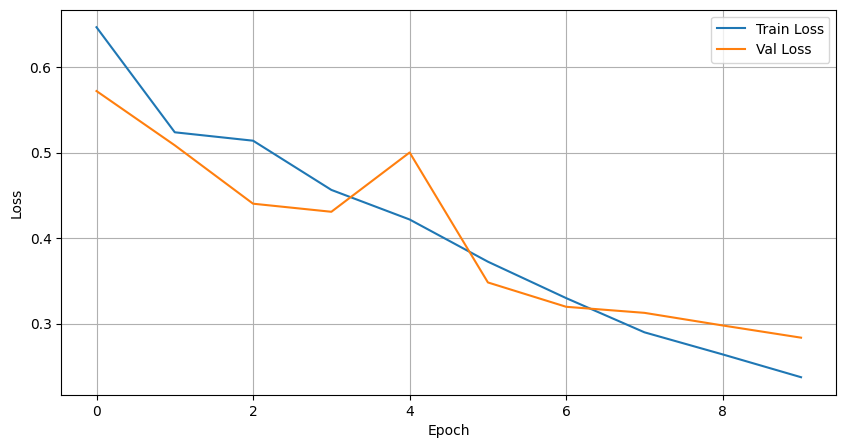

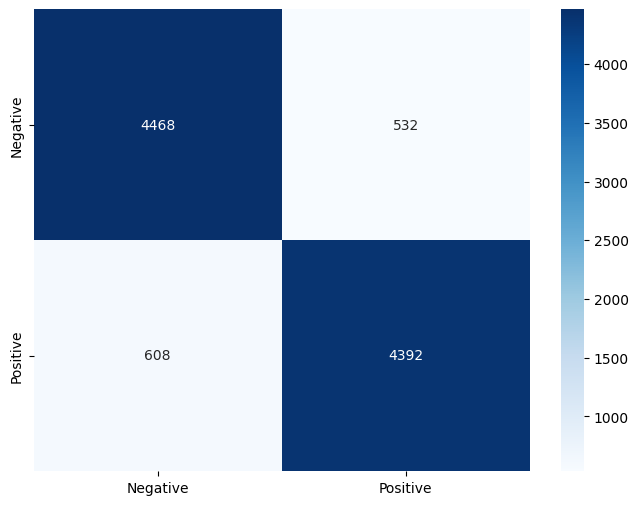

 Results discussion saved to ../results/lstm_improved/results_discussion.txt

 ALL DONE! LSTM Improved saved correctly!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

os.makedirs('../model', exist_ok=True)
os.makedirs('../results/lstm_improved', exist_ok=True)

torch.save(model.state_dict(), '../model/lstm_improved.pth')

# Loss curves
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('../results/lstm_improved/loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.savefig('../results/lstm_improved/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Metrics
with open('../results/lstm_improved/metrics.txt','w') as f:
    f.write("LSTM Improved Model - Evaluation Metrics\n\n")
    f.write(f"Test Accuracy: {test_accuracy:.2%}\n\n")
    f.write(classification_report(y_true, y_pred))

# results discussion
with open('../results/lstm_improved/results_discussion.txt', 'w') as f:
    f.write("="*50 + "\n")
    f.write("LSTM Improved - RESULTS DISCUSSION\n")
    f.write("="*50 + "\n\n")
    
    f.write(f"Model Performance:\n")
    f.write(f"- Test Accuracy: {test_accuracy:.2%}\n")
    f.write(f"- Training Accuracy (final): {train_accuracies[-1]:.2f}%\n")
    f.write(f"- Validation Accuracy (final): {val_accuracies[-1]:.2f}%\n\n")

print(" Results discussion saved to ../results/lstm_improved/results_discussion.txt")

print("\n" + "="*50)
print(" ALL DONE! LSTM Improved saved correctly!")
print("="*50)